In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy.*")

import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify  # 需确保已安装：pip install squarify
from collections import Counter
import ast

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def get_db_connection():
    """建立 StarRocks 数据库连接"""
    return pymysql.connect(
        host='192.168.144.101',
        port=9030,
        user='hadoop',
        password='hadoop',
        charset='utf8'
    )

def fetch_and_process_data():
    """
    从 StarRocks 获取 room_type_distribution 并完成全局聚合。
    """
    conn = get_db_connection()
    # 路径：catalog.db.table
    query = "SELECT room_type_distribution FROM iceberg_catalog.ershoufang.ads_city_overview_daily"
    
    try:
        df = pd.read_sql(query, conn)
        
        # 聚合所有行的 Map 数据
        total_counts = Counter()
        for item in df['room_type_distribution']:
            if not item: continue
            
            data = item
            if isinstance(item, str):
                try:
                    # 处理可能存在的 JSON 字符串或 Python 字典字符串
                    data = ast.literal_eval(item)
                except:
                    continue
            
            if isinstance(data, dict):
                total_counts.update(data)
        
        # 转换为 DataFrame
        result_df = pd.DataFrame(list(total_counts.items()), columns=['room_type', 'count'])
        # 仅取前 10 名热门户型，其余归为“其他”
        result_df = result_df.sort_values(by='count', ascending=False)
        top_10 = result_df.head(10).copy()
        
        return top_10
    
    finally:
        conn.close()

In [5]:
def plot_room_type_treemap():
    """矩形树图：带中心注释说明"""
    df = fetch_and_process_data()
    
    if df.empty:
        return

    # 数据准备
    sizes = df['count'].values
    # 构建标签：户型名称 + 百分比
    labels = [f"{row['room_type']}\n({row['count']/df['count'].sum():.1%})" for _, row in df.iterrows()]
    
    # 颜色设置：使用 seaborn 的柔和色调
    colors = sns.color_palette("Spectral", len(df))

    # --- 开始绘图 ---
    plt.figure(figsize=(14, 8))
    
    # 绘制矩形树图
    squarify.plot(
        sizes=sizes, 
        label=labels, 
        color=colors, 
        alpha=0.8, 
        edgecolor="white", 
        linewidth=2,
        text_kwargs={'fontsize': 11, 'fontweight': 'bold'}
    )

    # 图表修饰
    plt.title('全国二手房热门户型占比 (Top 10)', fontsize=16, pad=30)
    plt.axis('off') 
    plt.text(0.98, 0.02, "注释：户型 'X-Y-Z' 代表 'X室-Y厅-Z卫'", 
             ha='right', va='bottom', fontsize=12, fontweight='bold', color='#333333',
             transform=plt.gcf().transFigure, # 图形坐标系统 (0,0) 到 (1,1)
             bbox=dict(boxstyle="round,pad=0.3", edgecolor="#CCCCCC", facecolor="#EEEEEE", alpha=0.9) # 添加带边框的背景
            )

    plt.tight_layout()
    plt.show()

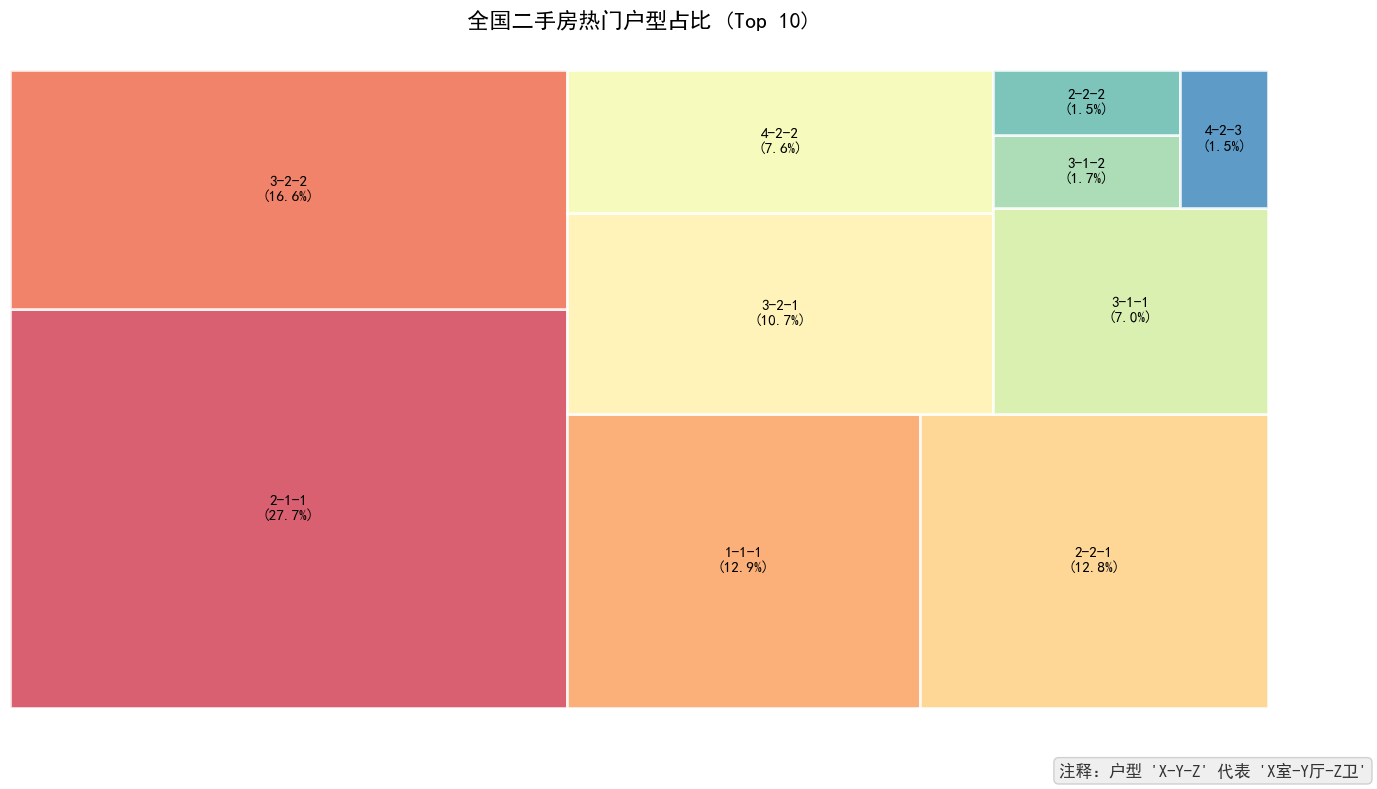

In [3]:
if __name__ == "__main__":
    plot_room_type_treemap()